In [15]:
# Solo carga y muestra nombres de columnas
ruta_oro = "C:/Users/Usuario/Desktop/TFFG/datasets/Datos históricos XAU_USD (1).csv"
ruta_btc = "C:/Users/Usuario/Desktop/TFFG/datasets/Datos históricos BTC_USD Bitfinex.csv"

# Leer primeras líneas sin parsear fechas
df_oro = pd.read_csv(ruta_oro, sep=";", encoding="utf-8")
df_btc = pd.read_csv(ruta_btc, sep=";", encoding="utf-8")

print("Columnas Oro:", df_oro.columns.tolist())
print("Columnas BTC:", df_btc.columns.tolist())


Columnas Oro: ['Fecha,"Último","Apertura","Máximo","Mínimo","Vol.","% var."']
Columnas BTC: ['Fecha,"Último","Apertura","Máximo","Mínimo","Vol.","% var."']


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7224\3857779966.py:54: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


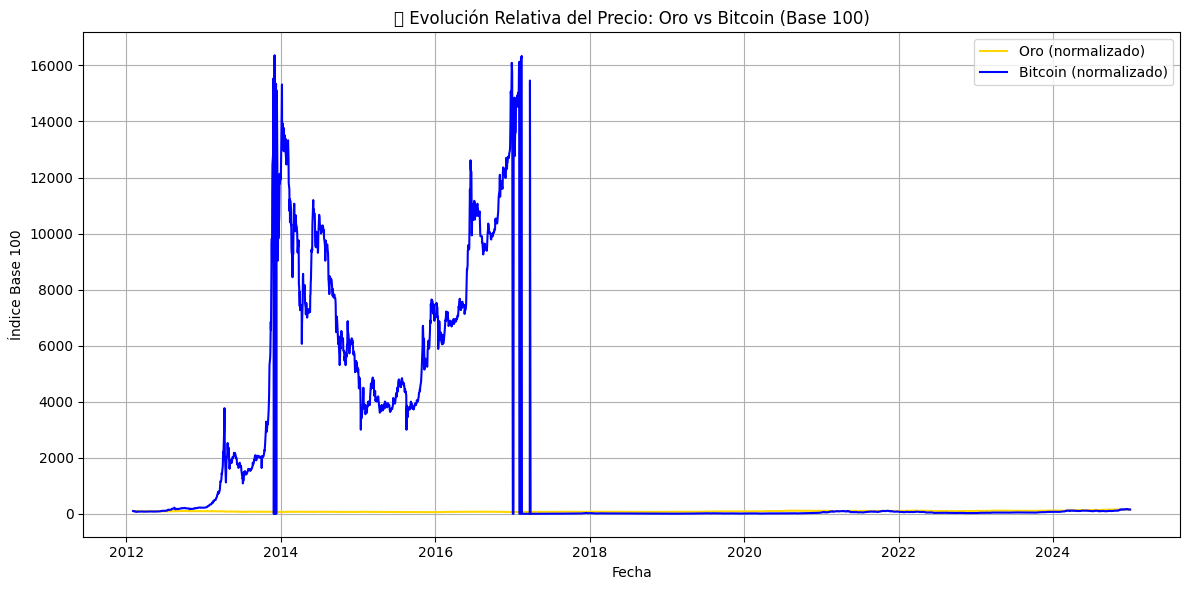

📌 Correlación entre oro y BTC (normalizados): -0.4829


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Rutas de archivos ===
ruta_oro = "C:/Users/Usuario/Desktop/TFFG/datasets/Datos históricos XAU_USD_2010.csv"
ruta_btc = "C:/Users/Usuario/Desktop/TFFG/datasets/Datos históricos BTC_USD Bitfinex.csv"

# === 2. Cargar archivos (separados por coma) ===
df_oro = pd.read_csv(ruta_oro, sep=",", encoding="utf-8")
df_btc = pd.read_csv(ruta_btc, sep=",", encoding="utf-8")

# === 3. Limpiar nombres de columnas ===
df_oro.columns = df_oro.columns.str.strip().str.replace('"', '').str.replace("﻿", "")
df_btc.columns = df_btc.columns.str.strip().str.replace('"', '').str.replace("﻿", "")

# === 4. Convertir fechas ===
df_oro["Fecha"] = pd.to_datetime(df_oro["Fecha"], dayfirst=True)
df_btc["Fecha"] = pd.to_datetime(df_btc["Fecha"], dayfirst=True)
df_oro = df_oro.sort_values("Fecha")
df_btc = df_btc.sort_values("Fecha")

# === 5. Seleccionar columnas y renombrar ===
df_oro = df_oro[["Fecha", "Último"]].rename(columns={"Último": "Precio_Oro"})
df_btc = df_btc[["Fecha", "Último"]].rename(columns={"Último": "Precio_BTC"})

# === 6. Convertir precios a numérico ===
df_oro["Precio_Oro"] = pd.to_numeric(df_oro["Precio_Oro"].astype(str).str.replace(",", ""), errors="coerce")
df_btc["Precio_BTC"] = pd.to_numeric(df_btc["Precio_BTC"].astype(str).str.replace(",", ""), errors="coerce")

# === 7. Unir por fecha común ===
merged = pd.merge(df_oro, df_btc, on="Fecha", how="inner")
merged = merged[merged["Fecha"] >= "2010-01-01"]  # ⬅️ FILTRAR DESDE 2010

# Eliminar precios de BTC que sean cero o NaN (inválidos)
merged = merged[(merged["Precio_BTC"] > 0) & (~merged["Precio_BTC"].isna())]

# Eliminar precios de Oro que sean cero o NaN (por seguridad)
merged = merged[(merged["Precio_Oro"] > 0) & (~merged["Precio_Oro"].isna())]


# === 8. Normalización base 100 ===
merged["Oro_norm"] = merged["Precio_Oro"] / merged["Precio_Oro"].iloc[0] * 100
merged["BTC_norm"] = merged["Precio_BTC"] / merged["Precio_BTC"].iloc[0] * 100

# === 9. Visualización ===
plt.figure(figsize=(12, 6))
plt.plot(merged["Fecha"], merged["Oro_norm"], label="Oro (normalizado)", color="gold")
plt.plot(merged["Fecha"], merged["BTC_norm"], label="Bitcoin (normalizado)", color="blue")
plt.title("📈 Evolución Relativa del Precio: Oro vs Bitcoin (Base 100)")
plt.xlabel("Fecha")
plt.ylabel("Índice Base 100")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 10. Correlación de precios normalizados ===
correlacion = merged[["Oro_norm", "BTC_norm"]].corr().iloc[0, 1]
print(f"📌 Correlación entre oro y BTC (normalizados): {correlacion:.4f}")


In [27]:
print(merged.describe())


                               Fecha   Precio_Oro   Precio_BTC     Oro_norm  \
count                           3359  3359.000000  3359.000000  3359.000000   
mean   2018-07-17 17:52:10.574575872     1.567005  1269.244782    89.034876   
min              2012-02-02 00:00:00     1.051740     1.003200    59.758294   
25%              2015-04-27 12:00:00     1.266865    10.519000    71.981375   
50%              2018-07-18 00:00:00     1.484500    46.301000    84.347070   
75%              2021-10-07 12:00:00     1.810895  1983.500000   102.892346   
max              2024-12-31 00:00:00     2.786190  9981.000000   158.307149   
std                              NaN     0.363419  2247.846038    20.648947   

           BTC_norm  
count   3359.000000  
mean    2080.729151  
min        1.644590  
25%       17.244262  
50%       75.903279  
75%     3251.639344  
max    16362.295082  
std     3684.993504  


In [28]:
print(merged[merged["Precio_BTC"] > 50000].head(10))  # Para ver precios anómalos


Empty DataFrame
Columns: [Fecha, Precio_Oro, Precio_BTC, Oro_norm, BTC_norm]
Index: []


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7224\3647828799.py:10: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


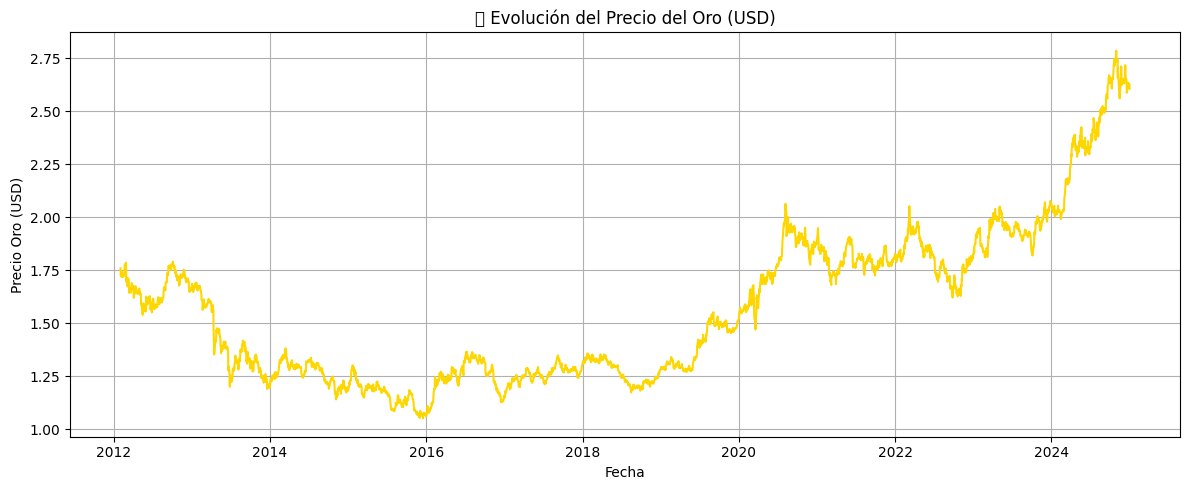

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7224\3647828799.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


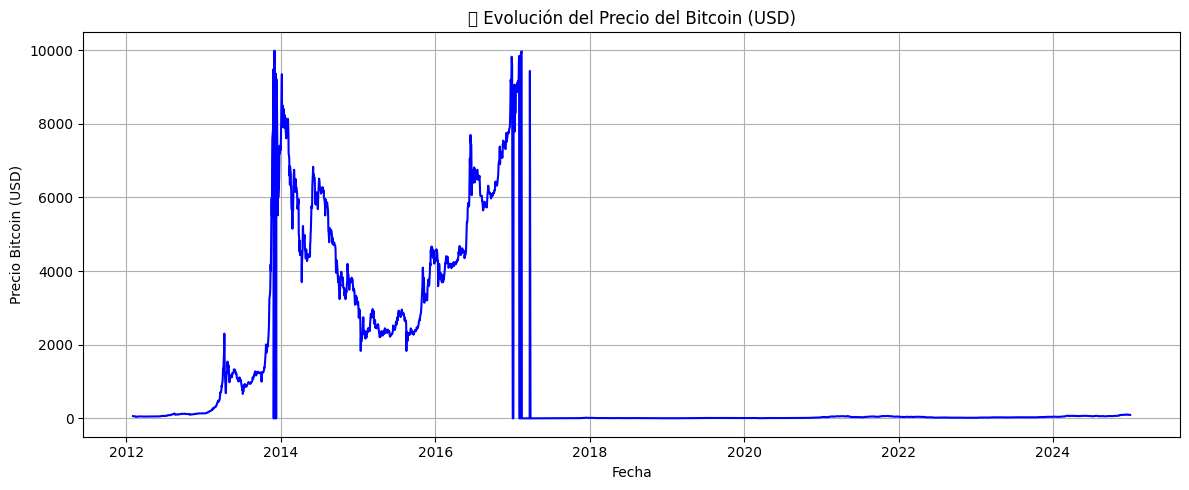

In [29]:
import matplotlib.pyplot as plt

# === 1. Graficar precio del Oro ===
plt.figure(figsize=(12, 5))
plt.plot(merged["Fecha"], merged["Precio_Oro"], color='gold')
plt.title("📈 Evolución del Precio del Oro (USD)")
plt.xlabel("Fecha")
plt.ylabel("Precio Oro (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

# === 2. Graficar precio del Bitcoin ===
plt.figure(figsize=(12, 5))
plt.plot(merged["Fecha"], merged["Precio_BTC"], color='blue')
plt.title("📈 Evolución del Precio del Bitcoin (USD)")
plt.xlabel("Fecha")
plt.ylabel("Precio Bitcoin (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7224\3790590446.py:32: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


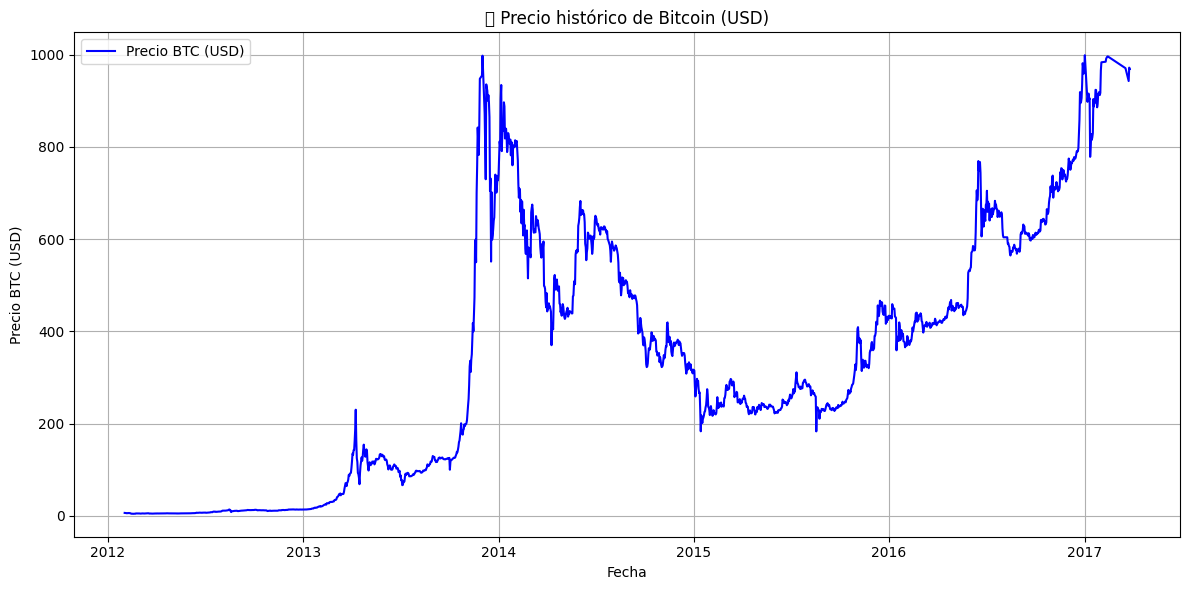

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Ruta del archivo
ruta_btc = "C:/Users/Usuario/Desktop/TFFG/datasets/Datos históricos BTC_USD Bitfinex.csv"

# Leer CSV respetando formato coma decimal y punto como separador
df_btc = pd.read_csv(ruta_btc, sep=",", encoding="utf-8")

# Limpiar nombres de columnas
df_btc.columns = df_btc.columns.str.strip().str.replace('"', '').str.replace("﻿", "")

# Convertir la columna de fecha
df_btc["Fecha"] = pd.to_datetime(df_btc["Fecha"], dayfirst=True, errors='coerce')

# Reemplazar comas decimales por puntos antes de convertir
df_btc["Último"] = df_btc["Último"].astype(str).str.replace(",", ".")
df_btc["Precio_BTC"] = pd.to_numeric(df_btc["Último"], errors="coerce")

# Ordenar y filtrar
df_btc = df_btc[["Fecha", "Precio_BTC"]].sort_values("Fecha")
df_btc.dropna(inplace=True)

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(df_btc["Fecha"], df_btc["Precio_BTC"], color="blue", label="Precio BTC (USD)")
plt.title("📈 Precio histórico de Bitcoin (USD)")
plt.xlabel("Fecha")
plt.ylabel("Precio BTC (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7224\990673471.py:55: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


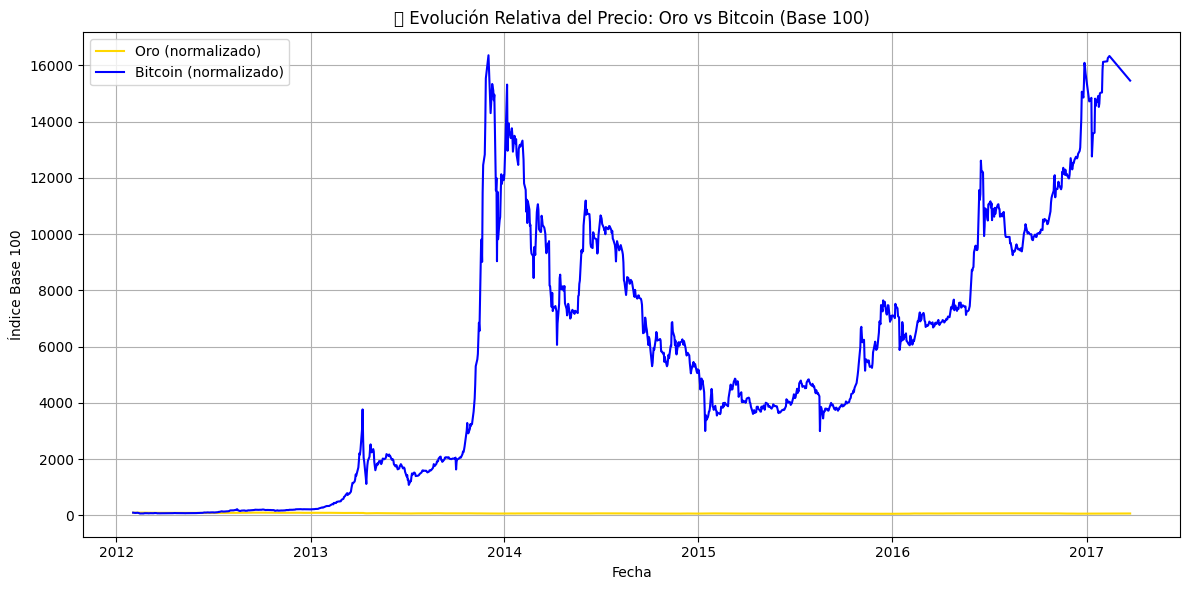

📌 Correlación entre oro y BTC (normalizados): -0.6188


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Rutas de archivos ===
ruta_oro = "C:/Users/Usuario/Desktop/TFFG/datasets/Datos históricos XAU_USD_2010.csv"
ruta_btc = "C:/Users/Usuario/Desktop/TFFG/datasets/Datos históricos BTC_USD Bitfinex.csv"

# === 2. Cargar archivos CSV ===
df_oro = pd.read_csv(ruta_oro, sep=",", encoding="utf-8")
df_btc = pd.read_csv(ruta_btc, sep=",", encoding="utf-8")

# === 3. Limpiar nombres de columnas ===
df_oro.columns = df_oro.columns.str.strip().str.replace('"', '').str.replace("﻿", "")
df_btc.columns = df_btc.columns.str.strip().str.replace('"', '').str.replace("﻿", "")

# === 4. Convertir fechas ===
df_oro["Fecha"] = pd.to_datetime(df_oro["Fecha"], dayfirst=True)
df_btc["Fecha"] = pd.to_datetime(df_btc["Fecha"], dayfirst=True)
df_oro = df_oro.sort_values("Fecha")
df_btc = df_btc.sort_values("Fecha")

# === 5. Seleccionar columnas y renombrar ===
df_oro = df_oro[["Fecha", "Último"]].rename(columns={"Último": "Precio_Oro"})
df_btc = df_btc[["Fecha", "Último"]].rename(columns={"Último": "Precio_BTC"})

# === 6. Corregir formato decimal y convertir precios ===
df_oro["Precio_Oro"] = pd.to_numeric(df_oro["Precio_Oro"].astype(str).str.replace(",", ""), errors="coerce")
df_btc["Precio_BTC"] = pd.to_numeric(df_btc["Precio_BTC"].astype(str).str.replace(",", "."), errors="coerce")

# === 7. Unir por fecha común ===
merged = pd.merge(df_oro, df_btc, on="Fecha", how="inner")
merged = merged[merged["Fecha"] >= "2010-01-01"]

# Eliminar valores inválidos
merged = merged[(merged["Precio_Oro"] > 0) & (~merged["Precio_Oro"].isna())]
merged = merged[(merged["Precio_BTC"] > 0) & (~merged["Precio_BTC"].isna())]

# === 8. Normalización base 100 desde el primer valor válido ===
merged = merged.sort_values("Fecha").reset_index(drop=True)
base_oro = merged["Precio_Oro"].iloc[0]
base_btc = merged["Precio_BTC"].iloc[0]

merged["Oro_norm"] = merged["Precio_Oro"] / base_oro * 100
merged["BTC_norm"] = merged["Precio_BTC"] / base_btc * 100

# === 9. Visualización ===
plt.figure(figsize=(12, 6))
plt.plot(merged["Fecha"], merged["Oro_norm"], label="Oro (normalizado)", color="gold")
plt.plot(merged["Fecha"], merged["BTC_norm"], label="Bitcoin (normalizado)", color="blue")
plt.title("📈 Evolución Relativa del Precio: Oro vs Bitcoin (Base 100)")
plt.xlabel("Fecha")
plt.ylabel("Índice Base 100")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 10. Correlación de precios normalizados ===
correlacion = merged[["Oro_norm", "BTC_norm"]].corr().iloc[0, 1]
print(f"📌 Correlación entre oro y BTC (normalizados): {correlacion:.4f}")


In [33]:
# 1. Revalorización relativa desde 2010
inicio = merged.iloc[0]
fin = merged.iloc[-1]

reval_oro = fin["Precio_Oro"] / inicio["Precio_Oro"] - 1
reval_btc = fin["Precio_BTC"] / inicio["Precio_BTC"] - 1

print(f"📊 Revalorización Oro: {reval_oro:.2%}")
print(f"📊 Revalorización Bitcoin: {reval_btc:.2%}")

if reval_btc > reval_oro:
    print("✅ Bitcoin ha tenido mayor revalorización relativa desde 2010.")
else:
    print("✅ El oro ha tenido mayor revalorización relativa desde 2010.")


📊 Revalorización Oro: -29.31%
📊 Revalorización Bitcoin: 15360.66%
✅ Bitcoin ha tenido mayor revalorización relativa desde 2010.


In [34]:
# 2. Correlación simple y visual
correlacion = merged[["Precio_Oro", "Precio_BTC"]].corr().iloc[0, 1]
print(f"📈 Correlación entre Oro y Bitcoin: {correlacion:.4f}")

if abs(correlacion) > 0.5:
    print("✅ Existe una correlación significativa.")
else:
    print("⚠️ No hay una correlación fuerte entre ambos activos.")


📈 Correlación entre Oro y Bitcoin: -0.6188
✅ Existe una correlación significativa.


In [35]:
# 3. Volatilidad móvil (30 días)
merged["Vol_Oro"] = merged["Precio_Oro"].pct_change().rolling(window=30).std()
merged["Vol_BTC"] = merged["Precio_BTC"].pct_change().rolling(window=30).std()

# Filtrar periodos donde la volatilidad de BTC supera claramente al oro
volatil_mayor = merged[merged["Vol_BTC"] > merged["Vol_Oro"] * 2]

print(f"📌 Días donde la volatilidad de BTC fue el doble que la del oro: {len(volatil_mayor)}")
print(volatil_mayor[["Fecha", "Vol_BTC", "Vol_Oro"]].head())


📌 Días donde la volatilidad de BTC fue el doble que la del oro: 1129
        Fecha   Vol_BTC   Vol_Oro
30 2012-03-15  0.053857  0.013379
31 2012-03-16  0.053802  0.012959
32 2012-03-19  0.054673  0.012971
33 2012-03-20  0.053754  0.012666
34 2012-03-21  0.053701  0.012626


In [36]:
# 4. Identificar caídas conjuntas (día a día)
merged["Ret_Oro"] = merged["Precio_Oro"].pct_change()
merged["Ret_BTC"] = merged["Precio_BTC"].pct_change()

caidas_conjuntas = merged[(merged["Ret_Oro"] < 0) & (merged["Ret_BTC"] < 0)]

print(f"📉 Días con caídas conjuntas: {len(caidas_conjuntas)}")
print(caidas_conjuntas[["Fecha", "Ret_Oro", "Ret_BTC"]].head())


📉 Días con caídas conjuntas: 272
        Fecha   Ret_Oro   Ret_BTC
1  2012-02-03 -0.019710 -0.016393
2  2012-02-06 -0.002898 -0.100000
4  2012-02-08 -0.007415 -0.017544
8  2012-02-14 -0.001393 -0.150943
21 2012-03-02 -0.002476 -0.040816


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7224\586586435.py:10: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


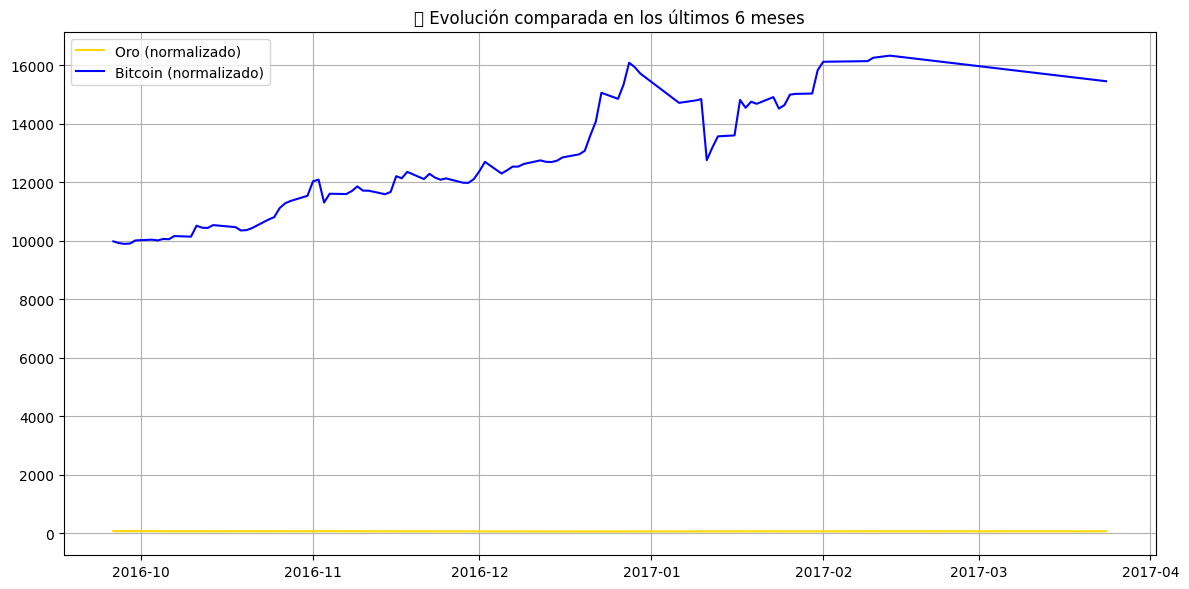

In [37]:
# 5. Comparar comportamiento relativo en los últimos 180 días
recent = merged[merged["Fecha"] >= merged["Fecha"].max() - pd.Timedelta(days=180)]

plt.figure(figsize=(12,6))
plt.plot(recent["Fecha"], recent["Oro_norm"], label="Oro (normalizado)", color="gold")
plt.plot(recent["Fecha"], recent["BTC_norm"], label="Bitcoin (normalizado)", color="blue")
plt.title("🔍 Evolución comparada en los últimos 6 meses")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
